<a href="https://colab.research.google.com/github/springboardmentorLive/Reality_AI/blob/bhaskar/logistic_regression_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
dataset = pd.read_csv('/content/user_dataset.csv')
dataset.head()


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603248,Female,27,57000,0
4,15804002,Male,19,76000,0


In [ ]:
#input
x = dataset.iloc[:,[2,3]].values
#output
y = dataset.iloc[:,4].values
#x,y

In [ ]:
#splitting the dataset:train and test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=0,shuffle=True)


In [ ]:
from sklearn.preprocessing import StandardScaler
sc_x = StandardScaler()
xtrain = sc_x.fit_transform(x_train)
xtest = sc_x.transform(x_test)

print(xtrain[0:10,:])

[[-0.07688044  0.86062693]
 [ 0.59582341 -1.61669171]
 [-1.15320661  0.56034588]
 [-0.21142121 -0.67831344]
 [-0.07688044 -0.11528647]
 [-1.28774738  0.78555667]
 [ 0.99944573  0.14745944]
 [ 0.59582341  1.83654033]
 [ 2.61393498 -1.35394579]
 [ 0.05766033 -0.34049726]]


In [ ]:
#traing logistic regrassion
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state=0)
classifier.fit(xtrain,y_train)

LogisticRegression(random_state=0)

In [ ]:
print(xtrain)

[[-0.07688044  0.86062693]
 [ 0.59582341 -1.61669171]
 [-1.15320661  0.56034588]
 [-0.21142121 -0.67831344]
 [-0.07688044 -0.11528647]
 [-1.28774738  0.78555667]
 [ 0.99944573  0.14745944]
 [ 0.59582341  1.83654033]
 [ 2.61393498 -1.35394579]
 [ 0.05766033 -0.34049726]
 [-0.07688044 -0.1528216 ]
 [-1.15320661 -1.57915658]
 [ 0.1922011   0.7104864 ]
 [-1.01866584  0.93569719]]


In [ ]:
#using model to do predictions on testing data
y_pred = classifier.predict(xtest)

In [ ]:
#evalution metrics
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)

print("confusion matrix : \n" , cm)

confusion matrix : 
 [[3 0]
 [0 3]]


In [ ]:
from sklearn.metrics import accuracy_score
print("accuracy : " , accuracy_score(y_test,y_pred))

accuracy :  1.0


In [ ]:
print(xtrain)

[[-0.07688044  0.86062693]
 [ 0.59582341 -1.61669171]
 [-1.15320661  0.56034588]
 [-0.21142121 -0.67831344]
 [-0.07688044 -0.11528647]
 [-1.28774738  0.78555667]
 [ 0.99944573  0.14745944]
 [ 0.59582341  1.83654033]
 [ 2.61393498 -1.35394579]
 [ 0.05766033 -0.34049726]
 [-0.07688044 -0.1528216 ]
 [-1.15320661 -1.57915658]
 [ 0.1922011   0.7104864 ]
 [-1.01866584  0.93569719]]


/tmp/ipython-input-1310280036.py:14: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_set[y_set==j,0],x_set[y_set==j,1],  c = ListedColormap(('red','green'))(i),label = j)


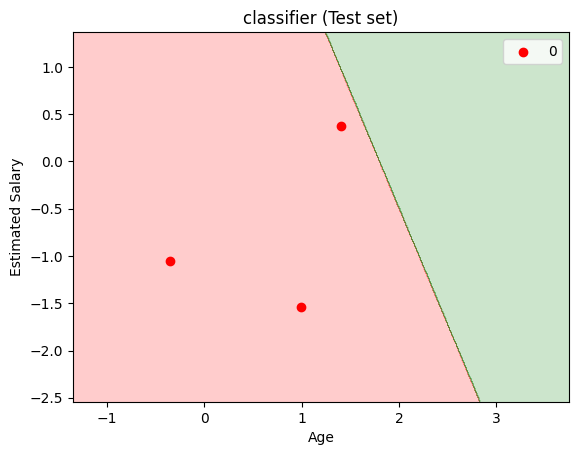

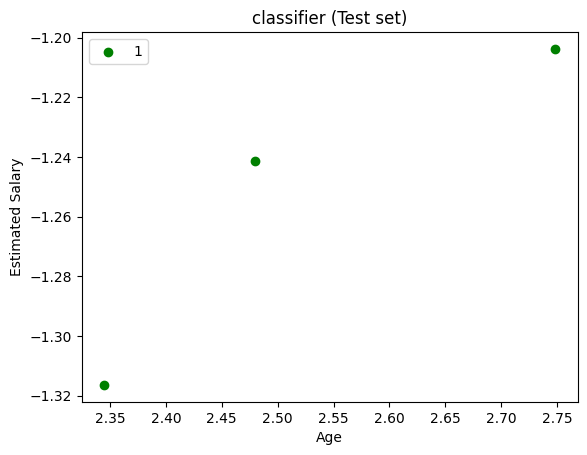

In [ ]:
#visuvilization
from matplotlib.colors import ListedColormap
x_set,y_set = xtest,y_test
x1, x2 = np.meshgrid(
    np.arange(start=x_set[:,0].min()-1, stop=x_set[:,0].max()+1, step=0.01),
    np.arange(start=x_set[:,1].min()-1, stop=x_set[:,1].max()+1, step=0.01)
)

plt.contourf(x1,x2,classifier.predict(np.array([x1.ravel(),x2.ravel()]).T).reshape(x1.shape),alpha=0.2,cmap=ListedColormap(('red','green')))
plt.xlim(x1.min(),x1.max())
plt.ylim(x2.min(),x2.max())

for i,j in enumerate(np.unique(y_set)):
  plt.scatter(x_set[y_set==j,0],x_set[y_set==j,1],  c = ListedColormap(('red','green'))(i),label = j)
  plt.title('classifier (Test set)')
  plt.xlabel('Age')
  plt.ylabel('Estimated Salary')
  plt.legend()
  plt.show()


In [ ]:
from PIL import Image
from PIL import ImageDraw
img = Image.open('/content/lovesymbol.jpg')
draw = ImageDraw.Draw(img)

draw.text((500,500),"Happy birthday",fill=(0,155,125))

img.save("output_image_with_text.jpg")
img.show()

In [ ]:
from PIL import Image
img = Image.open('/content/lovesymbol.jpg')
img.show()

resize_img = img.resize((200,200))

rotate_img = img.rotate(180)
rotate_img.save("rotated_img.jpg")
img.show()

img_crop = img.crop((0,0,100,100))
img_crop.save("cropped_img.jpg")

grayscal_img = img.convert('L')
grayscal_img.save("grayscale_img.jpg")
